# Week 9: Summarizing QB Data // Probabilities (Guided Notebook)

This notebook has two parts:

- **Part 1:** Summarize quarterback stats (means, standard deviations, histogram, boxplot + outliers)
- **Part 2:** Use survey data to compute probabilities and check independence

My goal is to show the results clearly and explain what they mean in normal language.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make tables easier to read in the notebook
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# I use this helper so loading files works whether the CSV is in my folder or /mnt/data

## Part 1: Summarizing QB Stats

Before plotting anything, I want to understand the dataset numerically.

We are doing:
- **Means** for each numeric column (typical value)
- **Standard deviations** for each numeric column (how spread out it is)
- A **histogram** for yards (shape of the distribution)
- A **boxplot** for touchdowns (and outliers)

In [87]:
# Load the QB dataset and check what it looks like
qb_path = resolve_csv("qb_stats.csv")
qb = pd.read_csv(qb_path)

print("qb shape:", qb.shape)
display(qb.head())

# Seeing column names helps later when I pick the yards and TD columns
print("\nColumns:")
print(list(qb.columns))

qb shape: (32, 13)


,name,team,games,att,cmp,comp_pct,yds,ypa,td,int,sack,loss,rating
0,Ryan Tannehill,TEN,12.0,286.0,201.0,70.3,2742.0,9.6,22.0,6.0,31.0,212.0,117.5
1,Drew Brees,NO,11.0,378.0,281.0,74.3,2979.0,7.9,27.0,4.0,12.0,89.0,116.3
2,Lamar Jackson,BAL,15.0,401.0,265.0,66.1,3127.0,7.8,36.0,6.0,23.0,106.0,113.3
3,Kirk Cousins,MIN,15.0,444.0,307.0,69.1,3603.0,8.1,26.0,6.0,28.0,206.0,107.4
4,Russell Wilson,SEA,16.0,516.0,341.0,66.1,4110.0,8.0,31.0,5.0,48.0,319.0,106.3



Columns:
['name', 'team', 'games', 'att', 'cmp', 'comp_pct', 'yds', 'ypa', 'td', 'int', 'sack', 'loss', 'rating']


### Why select numeric columns?

Mean and standard deviation only make sense for numbers.  
So first I filter down to numeric columns, then summarize those.

In [90]:
# Keep only numeric columns so summary stats don't get confused by text columns
qb_num = qb.select_dtypes(include="number")
print("Numeric columns:", list(qb_num.columns))

Numeric columns: ['games', 'att', 'cmp', 'comp_pct', 'yds', 'ypa', 'td', 'int', 'sack', 'loss', 'rating']


### Mean (average)

The mean is a “typical” value, but it can be pulled around by extreme values.  
Still, it is a good first summary to see the overall level of each stat.

In [93]:
# Means give a quick “typical value” for each numeric stat
means = qb_num.mean(numeric_only=True)
display(means.to_frame(name="mean").round(3))

,mean
games,14.125
att,478.406
cmp,306.562
comp_pct,64.297
yds,3515.062
ypa,7.375
td,22.375
int,10.344
sack,32.312
loss,217.094


### Interpretation (means)

These averages give me a quick sense of what a “normal” QB season looks like in this dataset.  
If one column has a much larger mean than the others, it usually means that stat is measured on a larger scale (like yards).

### Standard deviation (spread)

Standard deviation tells me how much values usually deviate from the mean.  
A larger standard deviation means the QBs are more different from each other in that stat.

In [97]:
# Standard deviation tells me how spread out each stat is (sample std is common in class settings)
stds = qb_num.std(numeric_only=True, ddof=1)
display(stds.to_frame(name="std_dev").round(3))

,std_dev
games,2.406
att,110.360
cmp,68.930
comp_pct,3.628
yds,852.437
ypa,0.797
td,6.257
int,5.840
sack,10.514
loss,70.786


### Interpretation (standard deviations)

If a column has a high standard deviation, it means the players vary a lot on that stat.  
If it is low, most players are clustered pretty closely together.

### Histogram (yards)

A histogram helps me see the *shape* of the distribution:
- Is it spread out or clustered?
- Is it skewed (more values on one side)?
- Are there multiple peaks?

For this assignment, I only need the histogram of **yards** with clear labels.

In [101]:
# I search by name so this still works if the column is called "Yds", "Yards", or something similar
yards_candidates = [c for c in qb.columns if "yd" in c.lower() or "yard" in c.lower()]
print("Yards candidates:", yards_candidates)

if len(yards_candidates) == 0:
    raise ValueError("No yards column found. Look at qb.columns and set yards_col manually.")

yards_col = yards_candidates[0]
print("Using yards_col =", yards_col)

Yards candidates: ['yds']
Using yards_col = yds


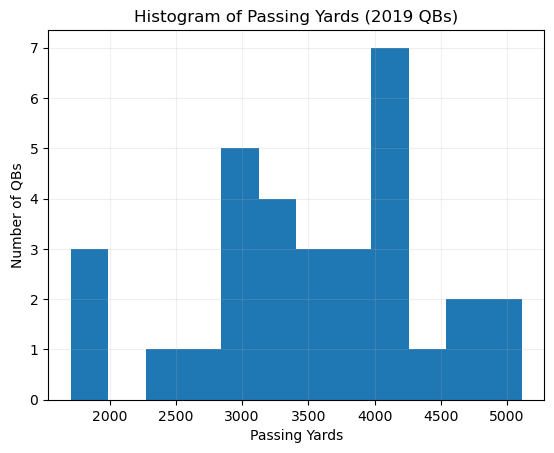

In [103]:
# Histogram shows the overall shape of the yards distribution (clustered vs spread vs skewed)
plt.figure()
plt.hist(qb[yards_col].dropna(), bins=12)

plt.title("Histogram of Passing Yards (2019 QBs)")
plt.xlabel("Passing Yards")
plt.ylabel("Number of QBs")
plt.grid(True, alpha=0.2)

plt.show()

### Interpretation (yards histogram)

This plot shows whether most QBs are grouped around a middle range or if the data leans high/low.  
If the bars stretch far to one side, that is usually skew. If I see one or two extreme values, that can hint at outliers.

### Boxplot (touchdowns) + outliers

A boxplot is great for spotting unusual values because it shows:
- The middle 50% (the box)
- The typical range (the whiskers)
- Points beyond the whiskers (possible outliers)

To *formally* identify outliers, I use the common **1.5 × IQR rule**.

In [107]:
# Same idea as yards: try to detect the TD column by name
td_candidates = [c for c in qb.columns if c.strip().lower() in ["td", "touchdowns"] or "touchdown" in c.lower()]
print("TD candidates:", td_candidates)

if len(td_candidates) == 0:
    raise ValueError("No TD column found. Look at qb.columns and set td_col manually.")

td_col = td_candidates[0]
print("Using td_col =", td_col)

TD candidates: ['td']
Using td_col = td


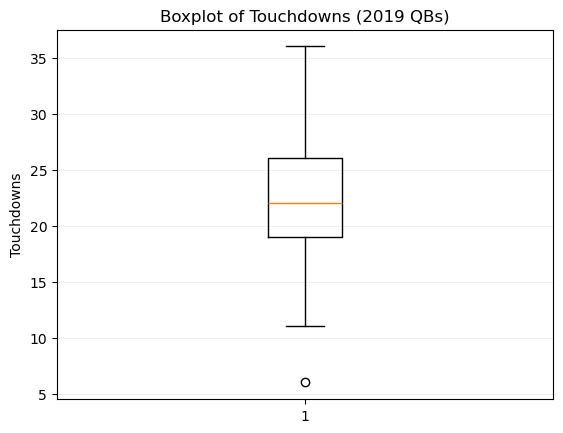

Q1=19.000, Q3=26.000, IQR=7.000
Outlier bounds: [8.500, 36.500]

Outliers found:


,name,td
24,Joe Flacco,6.0


In [109]:
# First: boxplot for a visual check
plt.figure()
plt.boxplot(qb[td_col].dropna(), vert=True)

plt.title("Boxplot of Touchdowns (2019 QBs)")
plt.ylabel("Touchdowns")
plt.grid(True, axis="y", alpha=0.2)

plt.show()

# Then: IQR method to identify outliers in a consistent way
td_series = qb[td_col].dropna()

q1 = td_series.quantile(0.25)
q3 = td_series.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = qb[(qb[td_col] < lower_bound) | (qb[td_col] > upper_bound)].copy()

print(f"Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}")
print(f"Outlier bounds: [{lower_bound:.3f}, {upper_bound:.3f}]")

# Show outliers clearly (and include a name column if the dataset has one)
name_candidates = [c for c in qb.columns if "player" in c.lower() or "name" in c.lower()]
name_col = name_candidates[0] if name_candidates else None

cols_to_show = []
if name_col:
    cols_to_show.append(name_col)
cols_to_show.append(td_col)

if outliers.empty:
    print("\nOutliers: None found using the 1.5×IQR rule.")
else:
    print("\nOutliers found:")
    display(outliers[cols_to_show].sort_values(td_col, ascending=False))

### Interpretation (touchdowns + outliers)

The boxplot gives a quick visual sense of what is normal vs unusual.  
The IQR method backs that up with a clear rule, so I can name exactly which values count as outliers instead of guessing.

## Part 2: Probabilities from Survey Data

Here I am treating each student as one observation.

I will calculate:
- P(brown hair)
- P(blue eyes)
- P(blue eyes | brown hair)
- P(brown hair | blue eyes)
- Independence check (are brown hair and blue eyes related or not?)

Then I will make bar charts for hair color and eye color.

In [113]:
# Load the survey dataset
survey_path = resolve_csv("survey_data.csv")
survey = pd.read_csv(survey_path)

print("survey shape:", survey.shape)
display(survey.head())

print("\nColumns:")
print(list(survey.columns))

# Try to auto-detect hair and eye columns by name
hair_candidates = [c for c in survey.columns if "hair" in c.lower()]
eye_candidates = [c for c in survey.columns if "eye" in c.lower()]

# Fallback: if detection fails, assume first two columns are hair and eye
if not hair_candidates or not eye_candidates:
    hair_col = survey.columns[0]
    eye_col = survey.columns[1]
else:
    hair_col = hair_candidates[0]
    eye_col = eye_candidates[0]

print("\nUsing columns:")
print("hair_col =", hair_col)
print("eye_col  =", eye_col)

survey shape: (162, 2)


,hair_color,eye_color
0,brown,brown
1,brown,brown
2,brown,blue
3,brown,green
4,brown,brown



Columns:
['hair_color', 'eye_color']

Using columns:
hair_col = hair_color
eye_col  = eye_color


### Cleaning categories (simple but important)

Survey data often has small inconsistencies like “Brown” vs “brown” or extra spaces.  
To avoid missing matches, I normalize the text by trimming whitespace and converting to lowercase.

In [116]:
# Normalize text so comparisons like == "brown" work reliably
survey[hair_col] = survey[hair_col].astype(str).str.strip().str.lower()
survey[eye_col] = survey[eye_col].astype(str).str.strip().str.lower()

# Quick counts help me see the category options in the dataset
print("Hair counts:\n", survey[hair_col].value_counts(), "\n")
print("Eye counts:\n", survey[eye_col].value_counts())

Hair counts:
 hair_color
brown     83
blonde    38
black     22
red        9
blond      5
other      3
gray       1
white      1
Name: count, dtype: int64 

Eye counts:
 eye_color
brown    64
green    41
blue     40
other     9
black     8
Name: count, dtype: int64


### Probabilities from data

When I compute probabilities from a dataset, I treat them like proportions:

- P(event) = (number of rows where event is true) / (total rows)

In pandas, a nice trick is that boolean values act like 1s and 0s, so `.mean()` gives the proportion.

In [119]:
# Probabilities from data are just proportions of rows where the event is true
n = len(survey)

# Events as boolean arrays
is_brown_hair = (survey[hair_col] == "brown")
is_blue_eyes = (survey[eye_col] == "blue")

# Basic probabilities (proportions)
p_brown = is_brown_hair.mean()
p_blue = is_blue_eyes.mean()

# Joint probability
p_blue_and_brown = (is_brown_hair & is_blue_eyes).mean()

# Conditional probabilities
p_blue_given_brown = p_blue_and_brown / p_brown if p_brown > 0 else np.nan
p_brown_given_blue = p_blue_and_brown / p_blue if p_blue > 0 else np.nan

print(f"Total students (n): {n}\n")
print("(a) P(brown hair) =", round(p_brown, 4))
print("(b) P(blue eyes)  =", round(p_blue, 4))
print("(c) P(blue eyes | brown hair) =", round(p_blue_given_brown, 4))
print("(d) P(brown hair | blue eyes) =", round(p_brown_given_blue, 4))

Total students (n): 162

(a) P(brown hair) = 0.5123
(b) P(blue eyes)  = 0.2469
(c) P(blue eyes | brown hair) = 0.2169
(d) P(brown hair | blue eyes) = 0.45


### Interpretation (probabilities)

The first two values are just overall proportions in the class sample.  
The conditional probabilities tell me how the probability changes once I “filter” the group.

If P(blue eyes | brown hair) is very different from P(blue eyes), that suggests hair color and eye color might be related.

### Independence check (the main idea)

Two events A and B are independent if knowing A does not change the probability of B.

A common rule to test this is:
- P(A and B) should equal P(A) * P(B)

If those are far apart, the events do not look independent in this dataset.

In [133]:
# Independence check compares P(A and B) to P(A)*P(B)
p_expected_if_independent = p_brown * p_blue  # Calculate expected probability if events are independent
difference = p_blue_and_brown - p_expected_if_independent  # Calculate difference between actual and expected probabilities

# Display the actual joint probability
print("P(brown and blue) =", round(p_blue_and_brown, 6))
# Display the expected joint probability if independent
print("P(brown)*P(blue)  =", round(p_expected_if_independent, 6))
# Display the difference between actual and expected probabilities
print("Difference        =", round(difference, 6))

# Small tolerance because this is a sample, not the full population
# Statistical fluctuations are expected in samples
tol = 0.02

# Check if the difference is within our tolerance threshold
if abs(difference) <= tol:
    print("\nConclusion: These are pretty close, so independence seems plausible in this sample.")
else:
    print("\nConclusion: These are not close, so brown hair and blue eyes do not look independent in this sample.")

P(brown and blue) = 0.111111
P(brown)*P(blue)  = 0.126505
Difference        = -0.015394

Conclusion: These are pretty close, so independence seems plausible in this sample.


In [131]:
# Assistant
# Independence check compares P(A and B) to P(A)*P(B)
p_expected_if_independent = p_brown * p_blue  # Calculate expected probability if events are independent
difference = p_blue_and_brown - p_expected_if_independent  # Calculate difference between actual and expected probabilities

# Display the actual joint probability
print("P(brown and blue) =", round(p_blue_and_brown, 6))
# Display the expected joint probability if independent
print("P(brown)*P(blue)  =", round(p_expected_if_independent, 6))
# Display the difference between actual and expected probabilities
print("Difference        =", round(difference, 6))

# Small tolerance because this is a sample, not the full population
# Statistical fluctuations are expected in samples
tol = 0.02

# Check if the difference is within our tolerance threshold
if abs(difference) <= tol:
    print("\nConclusion: These are pretty close, so independence seems plausible in this sample.")
else:
    print("\nConclusion: These are not close, so brown hair and blue eyes do not look independent in this sample.")

P(brown and blue) = 0.111111
P(brown)*P(blue)  = 0.126505
Difference        = -0.015394

Conclusion: These are pretty close, so independence seems plausible in this sample.


### Bar charts (hair + eye color)

Bar charts help me see:
- which categories are most common
- whether the distribution is balanced or dominated by one group

For this assignment, I make one bar chart for hair and one for eyes, with clear labels.

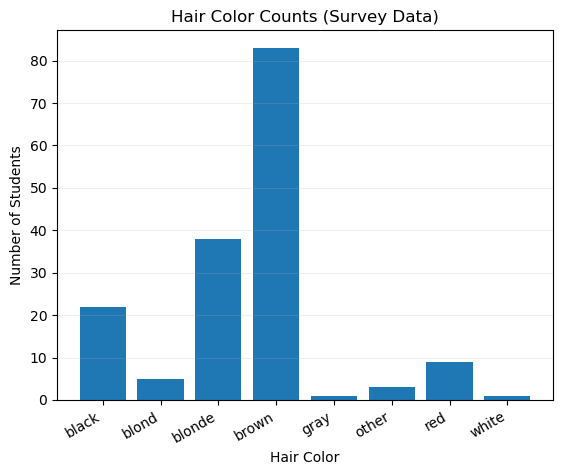

In [126]:
# Count each hair color (this becomes our bar heights)
hair_counts = survey[hair_col].value_counts().sort_index()

# Plot counts by category
plt.figure()
plt.bar(hair_counts.index, hair_counts.values)

# Label the chart so it stands on its own
plt.title("Hair Color Counts (Survey Data)")
plt.xlabel("Hair Color")
plt.ylabel("Number of Students")

# Rotate labels so categories stay readable
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.2)

plt.show()

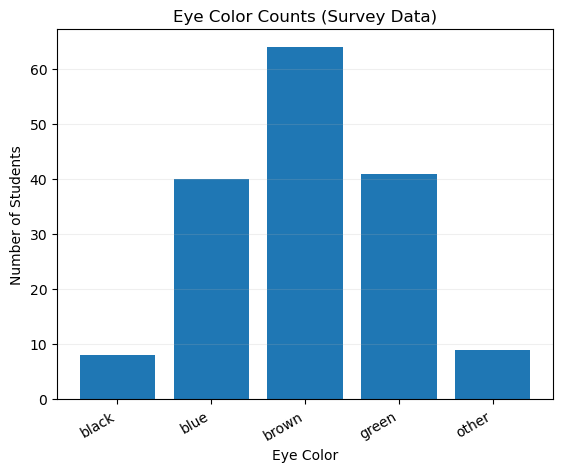

In [128]:
# Count each eye color (this becomes our bar heights)
eye_counts = survey[eye_col].value_counts().sort_index()

# Plot counts by category
plt.figure()
plt.bar(eye_counts.index, eye_counts.values)

# Label the chart so it stands on its own
plt.title("Eye Color Counts (Survey Data)")
plt.xlabel("Eye Color")
plt.ylabel("Number of Students")

# Rotate labels so categories stay readable
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.2)

plt.show()

## Final Checklist

Part 1 (qb_stats.csv)
- Mean of each numerical column printed
- Standard deviation of each numerical column printed
- Histogram of yards with labels
- Boxplot of touchdowns with labels
- Outliers identified using 1.5 × IQR

Part 2 (survey_data.csv)
- P(brown hair)
- P(blue eyes)
- P(blue eyes | brown hair)
- P(brown hair | blue eyes)
- Independence decision explained using probabilities
- Bar chart for hair color (labeled)
- Bar chart for eye color (labeled)